<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/Andrew_Karaoathy_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# nodes

In [2]:
import numpy as np

class nodes:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev = set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self._data}"

  def __add__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    add_out = nodes(self._data + other._data, (self, other), '+')
    def _backward():
      self._grad += 1.0 * add_out._grad
      other._grad += 1.0 * add_out._grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out =  nodes(self._data-other._data, (self, other), '-')
    def _backward():
      self._grad += 1.0 * out._grad
      other._grad += -1.0 * out._grad
    out._backward = _backward
    return out

  def __rsub__(self,other):
      return nodes(other, label=f"{other}")-self

  def __neg__(self):
      return self * -1

  def __mul__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out = nodes(self._data * other._data, (self, other), '*')
    def _backward():
      self._grad += other._data * out._grad
      other._grad += self._data * out._grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int,float)), "only float and int are supported"
    out = nodes(self._data ** other, (self,), f"**{other}")
    def _backward():
      self._grad += other * (self._data ** (other  - 1)) * out._grad
    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * (other**-1)

  def __rtruediv__(self, other):
    return nodes(other, label=f"{other}") / self

  def exp(self):
    out = nodes(np.exp(self._data), (self,), 'e')
    def _backward():
      self._grad += out._data * out._grad
    out._backward = _backward
    return out

  def log(self):
    out = nodes(np.log(self._data), (self,), 'log')
    def _backward():
      self._grad += (1.0 / self._data) * out._grad
    out._backward = _backward
    return out

  def tanh(self):
    e2x = (self * 2).exp()
    e2x._op = 'e^2x'
    out = (e2x - 1) *( (e2x + 1)**-1)
    out._op = 'tanh'
    return out

  def _sin(self):
    v = self._data
    out_sin = nodes(np.sin(v), (self,), 'sin')
    def _backward():
      self._grad += np.cos(v) * out_sin._grad
    out_sin._backward = _backward
    return out_sin

  def _cos(self):
    v = self._data
    out_cos = nodes(np.cos(v), (self,), 'cos')
    def _backward():
      self._grad += -np.sin(v) * out_cos._grad
    out_cos._backward = _backward
    return out_cos

  def backward(self):
    topo=[]
    visited=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self._grad = 1.0
    for node in reversed(topo):
      node._backward()

  def _zero_grad(self):
    self._grad = 0.0

### Mathematical Breakdown of `(self * 2).exp()`

1.  **`self * 2`**: This triggers `__mul__`. It creates a new node where the data is $x \times 2$ and the `_op` is `*`.
2.  **`.exp()`**: This triggers your `exp` method on that new node. It takes the data ($2x$) and returns `nodes(np.exp(data))`, which is $e^{2x}$.

This is why your `tanh` implementation works:
$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

In [ ]:
# @title
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"

    # Extract scalar values from potential node objects to prevent formatting errorsz
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4f}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

In [ ]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))

    # Safety check: extract raw scalar if the attribute is another node
    # This prevents 'TypeError: unsupported format string passed to nodes.__format__'
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    # Explicitly cast to float to support formatting codes like :.4f
    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4e}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

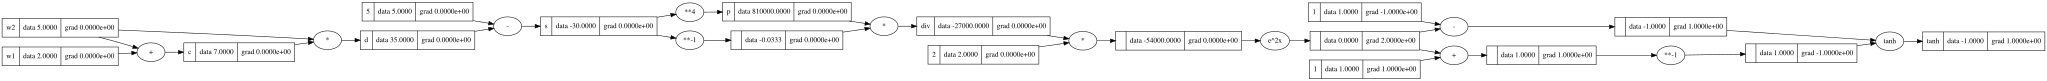

In [ ]:
draw_dot(tanh)

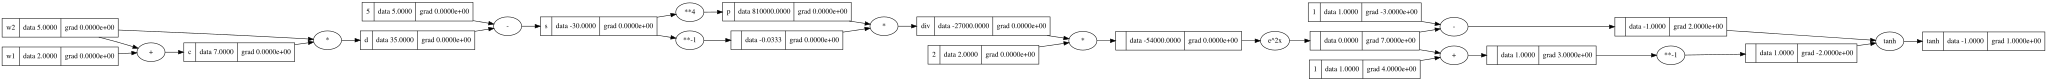

In [ ]:
tanh.backward()
draw_dot(tanh)


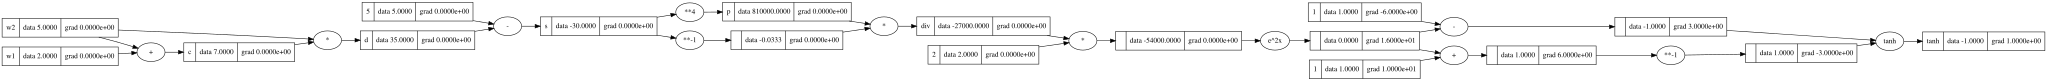

In [ ]:
tanh.backward()
draw_dot(tanh)

y data: 0.0997
x1 gradient: 0.1980


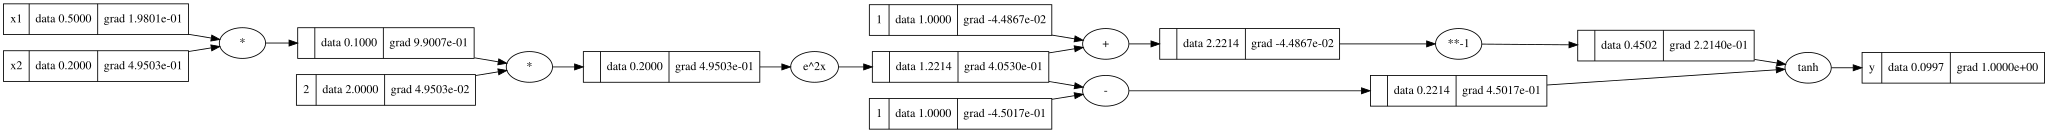

In [ ]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)

y data: 0.0997
x1 gradient: 0.1980


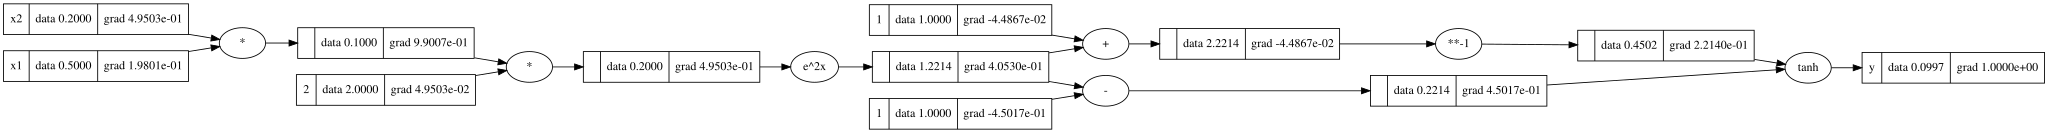

In [ ]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)

In [ ]:
a = nodes(2, label='a')
b = nodes(3, label='b')
c = nodes(4, label='c')
f = -a**3 + (3*b)._sin() - 1.0/c + b**2.5 - a**0.5
# df/da = -3*(a^2)- 0.5*(a^-0.5)
f.backward()
print(f._data)
# print(f(2, 3, 4))

6.336362190988558


In [ ]:
import math

# Manual calculation using values a=2, b=3, c=4
a_val, b_val, c_val = 2.0, 3.0, 4.0

# Derivatives
df_da = -3 * (a_val**2) - 0.5 * (a_val**-0.5)
df_db = 3 * math.cos(3 * b_val) + 2.5 * (b_val**1.5)
df_dc = 1.0 / (c_val**2)

print("--- Manual vs Autograd ---")
print(f"df/da: Manual = {df_da:.6f} | Autograd = {a._grad:.6f}")
print(f"df/db: Manual = {df_db:.6f} | Autograd = {b._grad:.6f}")
print(f"df/dc: Manual = {df_dc:.6f} | Autograd = {c._grad:.6f}")

# Check if results match closely
assert math.isclose(df_da, a._grad, rel_tol=1e-9)
assert math.isclose(df_db, b._grad, rel_tol=1e-9)
assert math.isclose(df_dc, c._grad, rel_tol=1e-9)
print("\nVerification successful: All gradients match!")

--- Manual vs Autograd ---
df/da: Manual = -12.353553 | Autograd = -12.353553
df/db: Manual = 10.256990 | Autograd = 10.256990
df/dc: Manual = 0.062500 | Autograd = 0.062500

Verification successful: All gradients match!


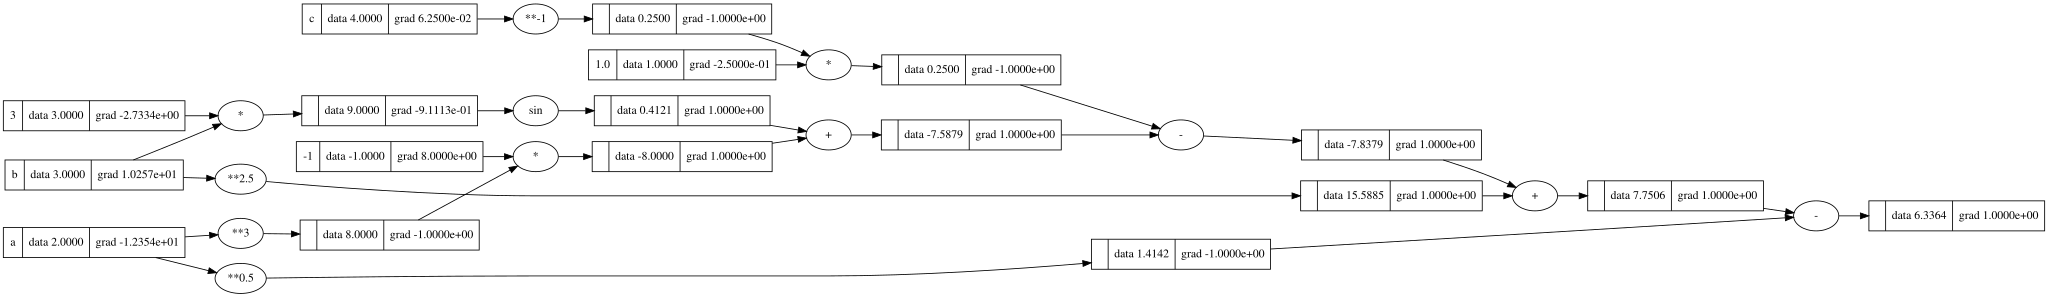

In [ ]:
draw_dot(f)

#Neural layer

neuron

In [ ]:
class neuron:
  def __init__(self, n_wt):
    self.w = [nodes(np.random.uniform(-1,1)) for _ in range(n_wt)]
    self.b = nodes(np.random.uniform(-1,1))

  def __call__(self, _inp):
    act = sum((wi*xi for wi, xi in zip(self.w, _inp)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

layer

In [ ]:
class layer:
  def __init__(self, n_wt, n_neu):
    self.neurons = [neuron(n_wt) for _ in range(n_neu)]

  def __call__(self, _inp):
    out = [n(_inp) for n in self.neurons]
    return out[0] if len(out) == 1 else out

  def parameters(self):
    return [p for n in self.neurons for p in n.parameters()]



In [ ]:
# @title
_in = [1,2,1,2,1]
n_wt = 5
n_neu = 3
_layer = layer(n_wt, n_neu)
out_nodes = _layer(_in) # Compute the output of the layer

# Reset gradients across the whole layer
for p in _layer.parameters():
  p._zero_grad()

out_nodes[0].backward() # Backpropagate from the first output node
draw_dot(out_nodes[0]) # Draw the graph for the first output node

multi layer

In [ ]:
class mlayer:
  def __init__(self, n_wt, n_neu, n_layer):
    # Comprehension: sets first layer input to n_wt, and last layer output to 1
    self.layers = [layer(n_wt if i == 0 else n_neu, 1 if i == n_layer - 1 else n_neu) for i in range(n_layer)]

  def __call__(self, x):
    for l in self.layers:
      x = l(x)
    return x

  def parameters(self):
    return [p for l in self.layers for p in l.parameters()]

In [ ]:
# @title

_in = [1,2,1]
n_wt = 3
n_neu = 3
n_layer = 3

# @title
# Initialize the MLP using the defined variables
# Note: parameters are (n_wt, n_neu, n_layer)
mlp = mlayer(n_wt, n_neu, n_layer)



In [ ]:
# @title

# Run a forward pass
mlp_out = mlp(_in)

print(f"Number of layers: {len(mlp.layers)}")
print(f"Number of parameters: {len(mlp.parameters())}")

# mlp_out = np.array(mlp_out, dtype=object)
print(f"Output nodes: {mlp_out}")

Number of layers: 3
Number of parameters: 28
Output nodes: 0.4119669067625494


In [ ]:
# @title
t_loss =  (1 - mlp_out)**2
# t_loss = sum(ind_loss)
# print(f"Output:{mi_mlp}")
# print(f"required output:{_tar}")
# print(f"loss:{ind_loss}")
print(f"loss:{t_loss}")



loss:0.34578291874240435


In [ ]:
# @title
# Zero the gradients for all parameters in the model
[p._zero_grad() for p in mlp.parameters()]
[p._grad for p in mlp.parameters()]


[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [ ]:
# @title
t_loss.backward()
[p._grad for p in mlp.parameters()]

[np.float64(-0.015966255170981637),
 np.float64(-0.031932510341963274),
 np.float64(-0.015966255170981637),
 np.float64(-0.015966255170981637),
 np.float64(0.024507135218696137),
 np.float64(0.049014270437392274),
 np.float64(0.024507135218696137),
 np.float64(0.024507135218696137),
 np.float64(0.18547096938042407),
 np.float64(0.37094193876084813),
 np.float64(0.18547096938042407),
 np.float64(0.18547096938042407),
 np.float64(0.13511100822765867),
 np.float64(-0.13112026638535856),
 np.float64(0.10421386830546552),
 np.float64(-0.1417774354461),
 np.float64(-0.6284423437344641),
 np.float64(0.6098801911052095),
 np.float64(-0.4847303599212912),
 np.float64(0.6594499218766784),
 np.float64(0.391433490199323),
 np.float64(-0.3798718119296746),
 np.float64(0.3019206113039001),
 np.float64(-0.4107469636720202),
 np.float64(-0.8377965556920497),
 np.float64(-0.5512157162440777),
 np.float64(-0.7345817970574958),
 np.float64(-0.9764680763760771)]

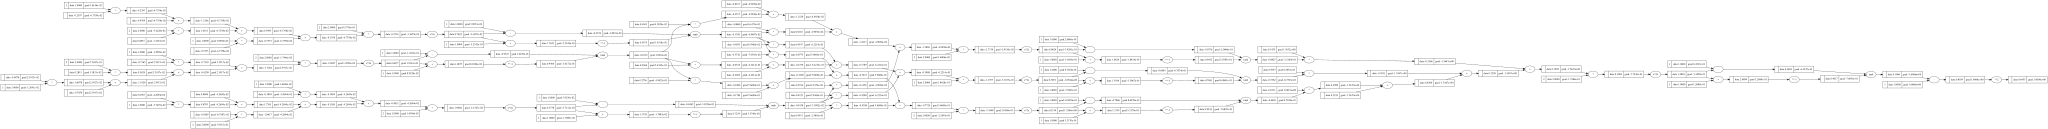

In [ ]:
# @title
draw_dot(t_loss)


In [ ]:
# @title
# Comprehension style update for all parameters
learning_rate = 0.01

# This performs the SGD update: p = p - lr * grad
# We use 'setattr' because assignment (p._data = ...) is not allowed inside a list comprehension
[setattr(p, '_data', p._data - learning_rate * p._grad) for p in mlp.parameters()]

print(f"Updated {len(mlp.parameters())} parameters.")
print("First 5 updated values:", [p._data for p in mlp.parameters()][:5])

Updated 28 parameters.
First 5 updated values: [np.float64(-0.48801715035231524), np.float64(0.2809497561978202), np.float64(-0.7167548946973921), np.float64(-0.7052926870351781), np.float64(-0.23902945290904198)]


putting the code in 1 section

In [ ]:

for _ in range(100):
  # Run a forward pass
  mlp_out = mlp(_in)

  print(f"Number of layers: {len(mlp.layers)}")
  print(f"Number of parameters: {len(mlp.parameters())}")

  # mlp_out = np.array(mlp_out, dtype=object)
  print(f"Output nodes: {mlp_out}")

  # Zero the gradients for all parameters in the model
  [p._zero_grad() for p in mlp.parameters()]
  # [p._grad for p in mlp.parameters()]

  # @title
  t_out =1
  t_loss =  ( t_out - mlp_out)**2
  # t_loss = sum(ind_loss)
  # print(f"Output:{mi_mlp}")
  # print(f"required output:{_tar}")
  # print(f"loss:{ind_loss}")
  print(f"loss:{t_loss}")



  t_loss.backward()
  # [p._grad for p in mlp.parameters()]

  # Comprehension style update for all parameters
  learning_rate = 0.01

  # This performs the SGD update: p = p - lr * grad
  # We use 'setattr' because assignment (p._data = ...) is not allowed inside a list comprehension
  [setattr(p, '_data', p._data - learning_rate * p._grad) for p in mlp.parameters()]

  print(f"Updated {len(mlp.parameters())} parameters.")
  print("First 5 updated values:", [p._data for p in mlp.parameters()][:5])


Number of layers: 3
Number of parameters: 28
Output nodes: -0.8289171965233766
loss:3.3449381117389274
Updated 28 parameters.
First 5 updated values: [np.float64(0.8156345823183043), np.float64(0.18732684174594577), np.float64(0.12434016919530003), np.float64(0.49476187220966483), np.float64(0.14831507210259737)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0.8084001823417402
loss:3.2703112194936392
Updated 28 parameters.
First 5 updated values: [np.float64(0.8163916388579243), np.float64(0.1888409548251857), np.float64(0.12509722573492), np.float64(0.4955189287492848), np.float64(0.14429983205740735)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0.7838309343394405
loss:3.1820528023063215
Updated 28 parameters.
First 5 updated values: [np.float64(0.8172062251717511), np.float64(0.19047012745283926), np.float64(0.12591181204874677), np.float64(0.4963335150631116), np.float64(0.13995531968545236)]
Number of layers: 3
Number of parameters: 28
Output nodes: -0

In [ ]:
print(mlp.parameters())

[0.34091683666481404, -0.4689950378050164, 0.2601600266337915, -0.4248205662572147, 0.9766078835577089, -0.28367628988671373, 0.46538661546873916, -0.010164473466666485, 0.8058572097226542, 0.32620801362631796, -0.0740388156273805, -0.7384363234914126, -0.3620838977668516, -0.1713057961027846, 0.7672563178362167, -1.0729641259848377, 0.6405233623680083, -0.6635351807487156, -1.0371843377436332, -0.13735128430091428, -0.3517414221156244, -0.732144630288583, -0.16917103481799659, -0.6786212373646455, -0.2705374220567604, -0.8068103871685398, -0.4001677052085438, 0.25963225201253154]


Another case implementtion with multi input

In [ ]:
# @title
_in = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
]
_tar = [0.7, 1, 0.9]

# Re-initialize the model here to get fresh random weights each time you run this cell
mlp = mlayer(n_wt, n_neu, n_layer)

mi_mlp = [mlp(_input) for _input in _in]
print(mi_mlp)

[-0.5733874386580029, -0.9160770887956075, -0.0009481812646083443]


loss

In [ ]:
# @title
ind_loss =  [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
t_loss = sum(ind_loss)
print(f"Output:{mi_mlp}")
print(f"required output:{_tar}")
print(f"loss:{ind_loss}")
print(f"loss:{t_loss}")

Output:[0.5215892211548634, 0.6248801349190575, 0.5571556858779994]
required output:[8, -10, 0.9]
loss:[55.92662777714712, 112.88807788139762, 0.11754222372578507]
loss:168.93224788227053


gradient

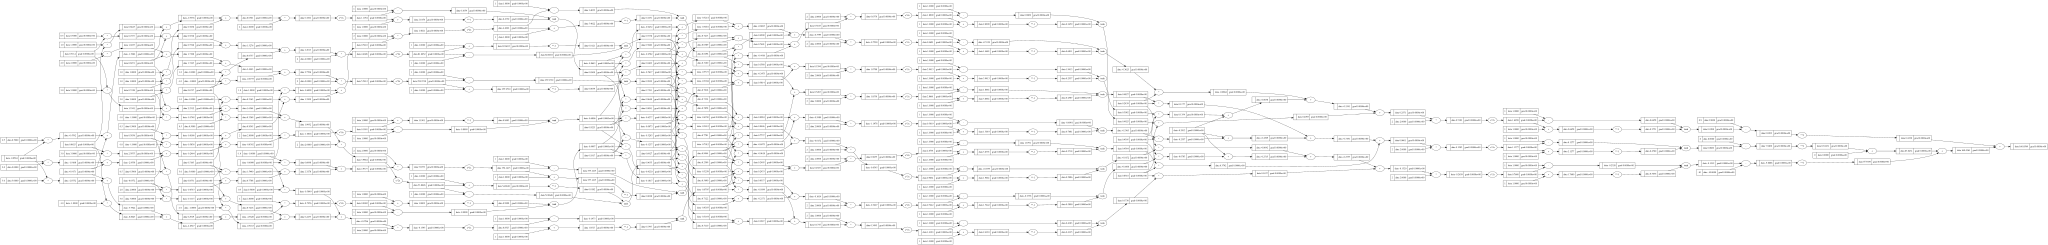

In [ ]:
draw_dot(t_loss)


In [ ]:
# @title
# Zero the gradients for all parameters in the model
[p._zero_grad() for p in mlp.parameters()]

t_loss.backward()
# draw_dot(t_loss)

all in A go

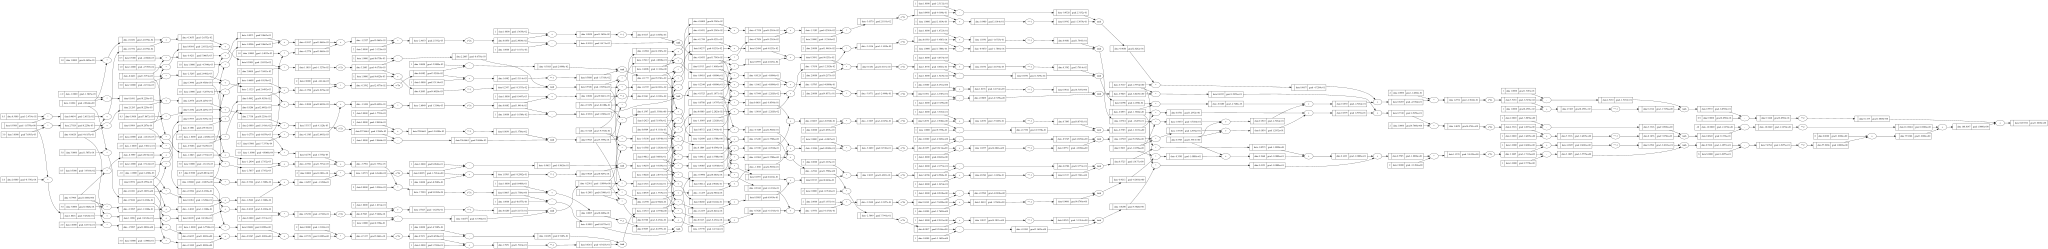

In [ ]:
# @title
# ALWAYS follow this order for a clean state:

# 1. Forward Pass: Creates NEW nodes for the graph (fresh _grad = 0.0 for intermediates)
mi_mlp = [mlp(_input) for _input in _in]
ind_loss = [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
t_loss = sum(ind_loss)

# 2. Zero Gradients: Clear the persistent weight/bias nodes
for p in mlp.parameters():
    p._zero_grad()

# 3. Backward Pass: Populate gradients in the fresh graph
t_loss.backward()

# Now the visualization will show exactly the gradients for THIS single pass
draw_dot(t_loss)


In [ ]:
learning_rate = 0.8 # Further increased to combat tanh saturation
for epoch in range(5001):
  # 1. Forward pass
  mi_mlp = [mlp(_input) for _input in _in]
  ind_loss = [(_rout - _out)**2 for _out, _rout in zip(mi_mlp, _tar)]
  t_loss = sum(ind_loss)

  # 2. Zero gradients
  [p._zero_grad() for p in mlp.parameters()]

  # 3. Backward pass
  t_loss.backward()

  # 4. Update parameters
  for p in mlp.parameters():
    p._data -= learning_rate * p._grad

  if epoch % 500 == 0:
    print(f"Epoch {epoch} | Loss: {t_loss._data:.6f} | Outputs: {[float(o._data) for o in mi_mlp]}")

print(f"\nFinal Loss: {t_loss._data:.6f}")
print(f"Final Outputs: {[float(o._data) for o in mi_mlp]}")
print(f"Targets: {_tar}")

Epoch 0 | Loss: 0.000066 | Outputs: [0.6943462298393458, 0.994468602376848, 0.8981514065277775]
Epoch 500 | Loss: 0.000119 | Outputs: [0.6913059370081178, 0.9943699970821674, 0.8965176000305777]
Epoch 1000 | Loss: 0.000053 | Outputs: [0.6947607700647138, 0.9953809178569222, 0.8978359418011875]
Epoch 1500 | Loss: 0.000043 | Outputs: [0.6952598777759613, 0.9959889073471031, 0.8980012210827281]
Epoch 2000 | Loss: 0.000036 | Outputs: [0.6955615876591179, 0.9964094903792318, 0.898099322075631]
Epoch 2500 | Loss: 0.000028 | Outputs: [0.6961814636038313, 0.9967238354651741, 0.8983440980971661]
Epoch 3000 | Loss: 0.000022 | Outputs: [0.696696802123837, 0.9969677314940468, 0.8985524207005308]
Epoch 3500 | Loss: 0.000021 | Outputs: [0.6967314473958128, 0.9971631628475912, 0.8985551726945077]
Epoch 4000 | Loss: 0.000019 | Outputs: [0.696842009688055, 0.9973266883602839, 0.898593518889568]
Epoch 4500 | Loss: 0.000016 | Outputs: [0.6971059022475891, 0.9974652374900254, 0.8987022219532615]
Epoch 500

# softmax

In [ ]:
# @title
def softmax(logits):
    # logits is a list of nodes objects
    counts = [logit.exp() for logit in logits]
    denominator = sum(counts)
    out = [c / denominator for c in counts]
    return out

# Apply softmax to your MLP output
probs = softmax(mlp_out)
for i, p in enumerate(probs):
    p._label = f"prob_{i}"
    print(f"Probability {i}: {p._data:.4f}")

Probability 0: 0.4088
Probability 1: 0.1368
Probability 2: 0.4544


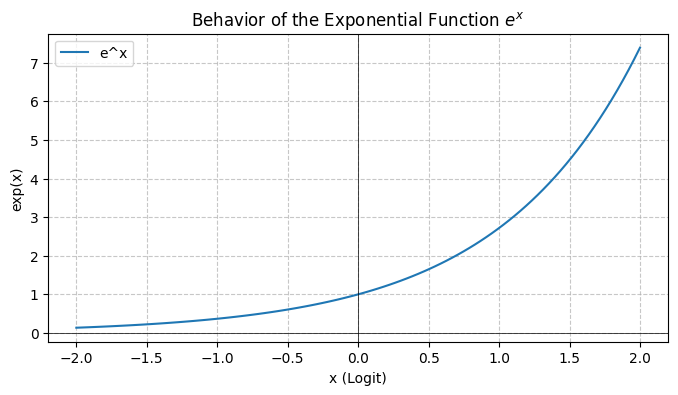

In [3]:
# @title
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 100)
y = np.exp(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label='e^x')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Behavior of the Exponential Function $e^x$")
plt.xlabel("x (Logit)")
plt.ylabel("exp(x)")
plt.legend()
plt.show()

In [ ]:
# @title
# Define a target (e.g., class 0)
target = [1.0, 0.0, 0.0]

# Recalculate probs to ensure nodes have the new 'log' method
probs = softmax(mlp_out)

# Cross-Entropy Loss: -sum(target_i * log(prob_i))
loss = sum([-(t * p.log()) for p, t in zip(probs, target)])
loss._label = 'cross_entropy_loss'

print(f"Cross-Entropy Loss: {loss._data:.4f}")

# Reset gradients before backprop
for p in mlp.parameters():
    p._zero_grad()

loss.backward()
print("Backpropagation complete with Cross-Entropy.")

Cross-Entropy Loss: 0.8946
Backpropagation complete with Cross-Entropy.


In [ ]:
# @title
learning_rate = 0.01

# Update each parameter using gradient descent
for p in mlp.parameters():
    p._data -= learning_rate * p._grad

# Run a second forward pass to see if the loss decreased
mlp_out_new = mlp(_in)
probs_new = softmax(mlp_out_new)
loss_new = sum([-(t * p.log()) for p, t in zip(probs_new, target)])

print(f"Initial Loss: {loss._data:.4f}")
print(f"Loss after 1 step of SGD: {loss_new._data:.4f}")
print(f"Loss reduction: {loss._data - loss_new._data:.4f}")

Initial Loss: 0.8946
Loss after 1 step of SGD: 0.8871
Loss reduction: 0.0076


In [ ]:
# @title
epochs = 50
learning_rate = 0.1 # Increasing learning rate for faster visible convergence

print(f"Starting training loop for {epochs} epochs...")

for i in range(epochs):
    # 1. Forward pass
    out = mlp(_in)
    probs = softmax(out)

    # 2. Compute Cross-Entropy Loss
    loss = sum([-(t * p.log()) for p, t in zip(probs, target)])

    # 3. Backward pass (Zero grad first)
    for p in mlp.parameters():
        p._zero_grad()
    loss.backward()

    # 4. Update parameters
    for p in mlp.parameters():
        p._data -= learning_rate * p._grad

    if i % 10 == 0 or i == epochs - 1:
        print(f"Epoch {i}: Loss {loss._data:.4f}")

print("\nFinal probabilities:")
for idx, p in enumerate(probs):
    print(f" Class {idx}: {p._data:.4f}")

Starting training loop for 50 epochs...
Epoch 0: Loss 0.8871
Epoch 10: Loss 0.8140
Epoch 20: Loss 0.7896
Epoch 30: Loss 0.7751
Epoch 40: Loss 0.7619
Epoch 49: Loss 0.7441

Final probabilities:
 Class 0: 0.4752
 Class 1: 0.0795
 Class 2: 0.4453


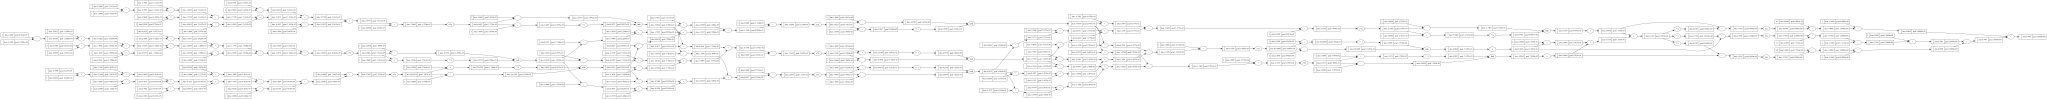

In [ ]:
draw_dot(loss)